<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/HRD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 1.062 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 2.133 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.040 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 0.657 detik


41666654166667500000

**Load Dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [4]:
data = pd.read_csv("/content/HR_comma_sep.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

display(data.head())
print("\nNew columns after selection:")
print(data.columns.tolist())

Preview data:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Checking for missing values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident         

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



New columns after selection:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


**Correlation Matrix**

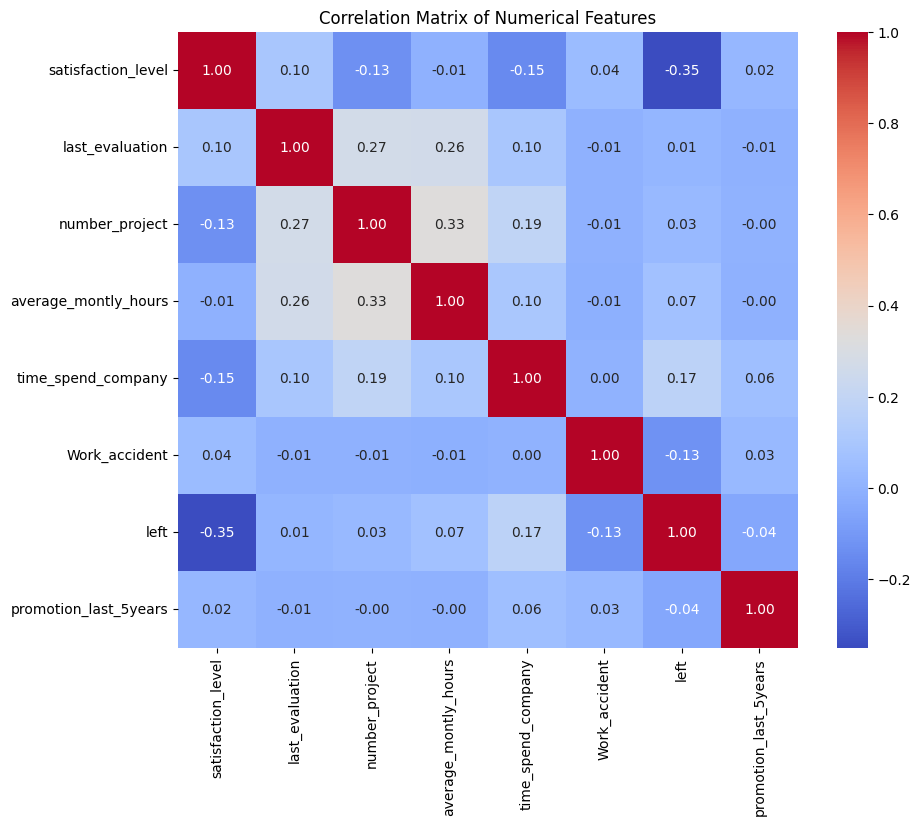

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Correlation Matrix**

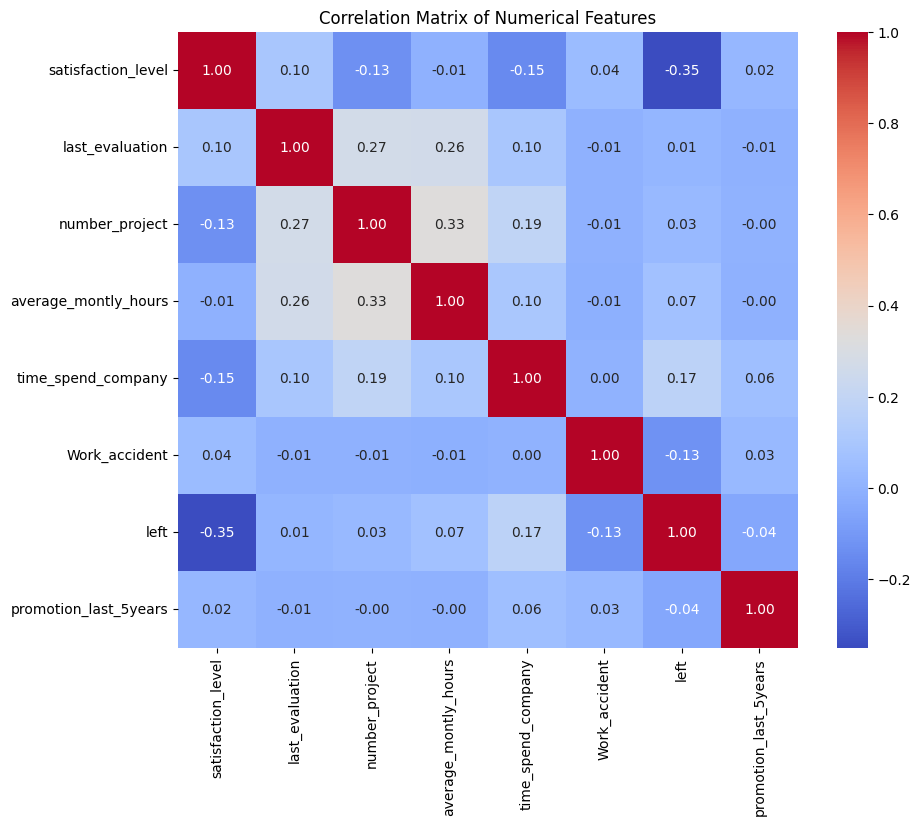

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Encoding Kolom Kategorikal**

In [8]:
print('Kolom sebelum encoding:', data.columns.tolist())

# Identifikasi kolom kategorikal
categorical_cols = ['Department', 'salary'] # Perbaikan: 'Department' menjadi 'department'

# Lakukan One-Hot Encoding
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print('\nKolom setelah encoding:')
print(data.columns.tolist())
display(data.head())

Kolom sebelum encoding: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Kolom setelah encoding:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department_RandD', 'Department_accounting', 'Department_hr', 'Department_management', 'Department_marketing', 'Department_product_mng', 'Department_sales', 'Department_support', 'Department_technical', 'salary_low', 'salary_medium']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


/tmp/ipython-input-961497737.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='left', data=data, palette='viridis')


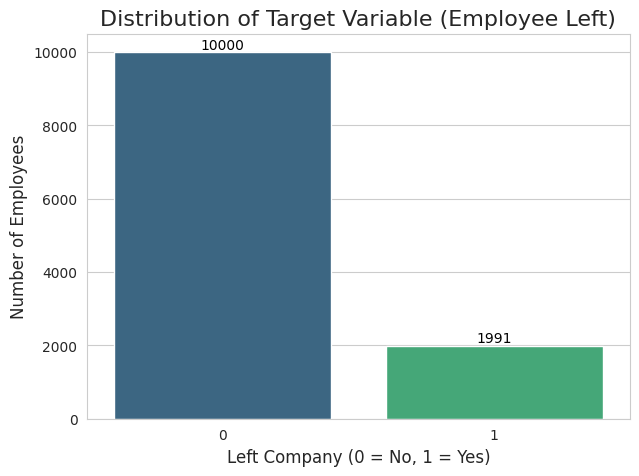

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Create a figure and an axes object
plt.figure(figsize=(7, 5))

# Create a count plot for the 'left' column
sns.countplot(x='left', data=data, palette='viridis')

# Add titles and labels
plt.title('Distribution of Target Variable (Employee Left)', fontsize=16)
plt.xlabel('Left Company (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

# Add value counts on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

/tmp/ipython-input-1352452994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='left', y=col, data=data, ax=axes[i], palette='viridis')
/tmp/ipython-input-1352452994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='left', y=col, data=data, ax=axes[i], palette='viridis')
/tmp/ipython-input-1352452994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='left', y=col, data=data, ax=axes[i], palette='viridis')


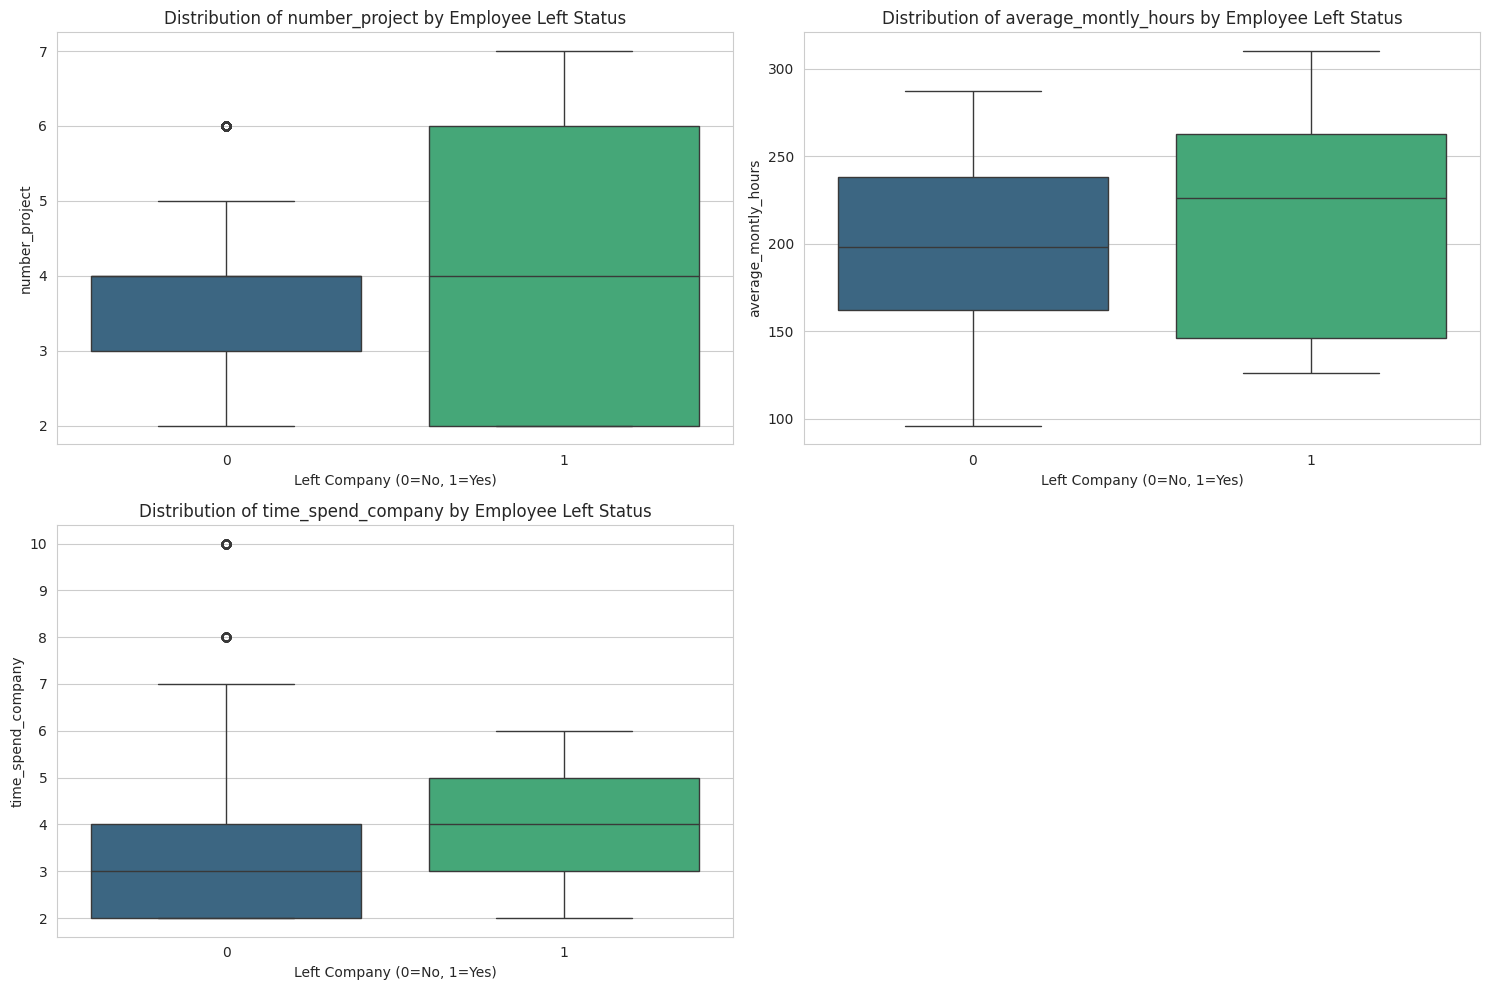

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plotting some key numerical features against the 'left' status
relevant_numerical_cols = ['number_project', 'average_montly_hours', 'time_spend_company']

# Set up the matplotlib figure and axes for subplots
n_cols = 2  # You can adjust this for more columns if needed
n_rows = (len(relevant_numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(relevant_numerical_cols):
    sns.boxplot(x='left', y=col, data=data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col} by Employee Left Status')
    axes[i].set_xlabel('Left Company (0=No, 1=Yes)')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

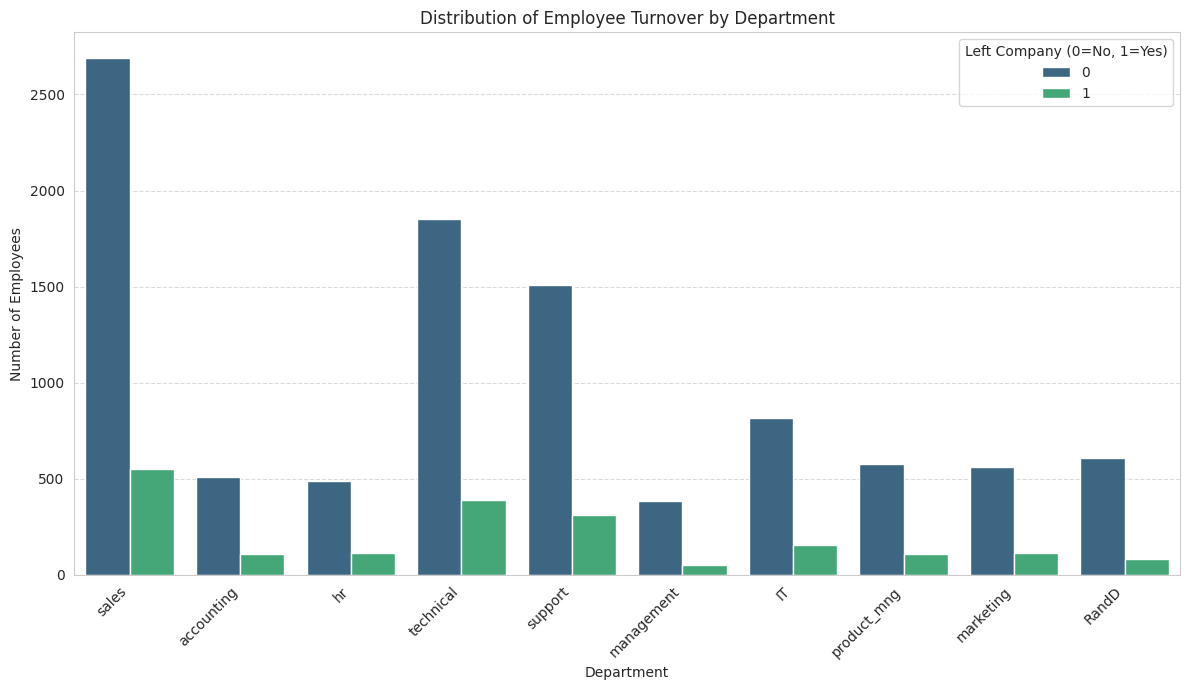

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The original 'department' column was removed after one-hot encoding in a previous step.
# To plot the distribution by the original department, we need to load the data again
# or use a copy of the DataFrame before encoding for this specific visualization.

# Load the dataset into a temporary DataFrame for plotting to get the original 'department' column
temp_data = pd.read_csv("/content/HR_comma_sep.csv")

# Ensure duplicates are handled consistently with the main 'data' DataFrame if needed
temp_data.drop_duplicates(inplace=True)

plt.figure(figsize=(12, 7))
sns.countplot(data=temp_data, x='Department', hue='left', palette='viridis')
plt.title('Distribution of Employee Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Left Company (0=No, 1=Yes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Number of rows before dropping NaNs: 11991
Number of rows after dropping NaNs: 11991


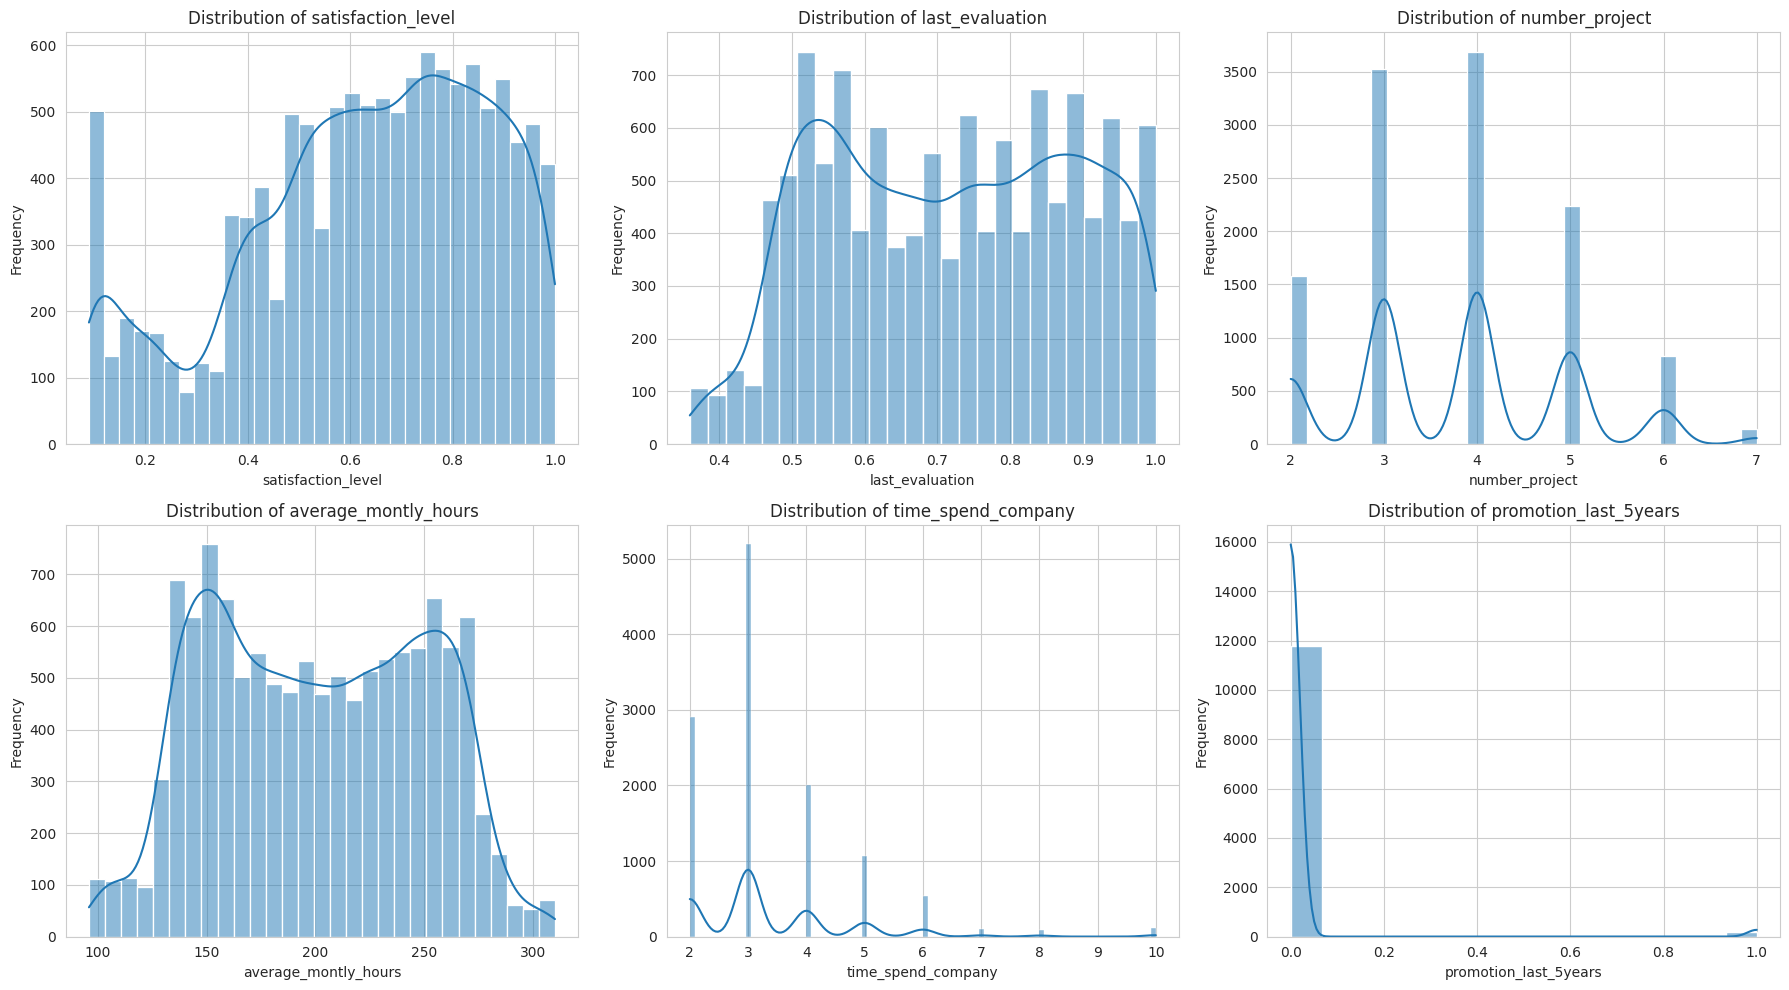


Skewness of numerical features after dropping NaNs:
satisfaction_level      -0.538702
last_evaluation         -0.031686
number_project           0.332152
average_montly_hours     0.027208
time_spend_company       1.816577
promotion_last_5years    7.490008
dtype: float64


In [15]:
print(f"Number of rows before dropping NaNs: {len(data)}")
data.dropna(inplace=True)
print(f"Number of rows after dropping NaNs: {len(data)}")

# Update numerical_cols_to_plot with actual columns from the HR dataset
numerical_cols_to_plot = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'promotion_last_5years'
]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_to_plot):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('\nSkewness of numerical features after dropping NaNs:')
print(data[numerical_cols_to_plot].skew())

In [16]:
print("Distribution of 'Work_accident' column:")
print(data['Work_accident'].value_counts())

Distribution of 'Work_accident' column:
Work_accident
0    10141
1     1850
Name: count, dtype: int64


In [17]:
# Define the desired sample sizes for the 'left' column
# Since class '0' is majority and '1' is minority, it's common to undersample the majority
# to match the minority class count, or set a specific number.
# Let's target the minority class count for both for a balanced dataset.

# First, get the count of the minority class (class 1 for 'left')
minority_class_count = data['left'].value_counts()[1]
print(f"Jumlah sampel kelas minoritas ('left'=1): {minority_class_count}")

sample_sizes = {
    0: minority_class_count, # Sample '0' class to match '1' class count
    1: minority_class_count  # Sample '1' class to its own count
}

# List to hold sampled dataframes
sampled_dfs = []

# Sample each category
for category, size in sample_sizes.items():
    current_category_df = data[data['left'] == category]
    if len(current_category_df) < size:
        print(f"Warning: Not enough samples for '{category}'. Available: {len(current_category_df)}. Desired: {size}. Sampling all available.")
        sampled_dfs.append(current_category_df)
    else:
        sampled_dfs.append(current_category_df.sample(n=size, random_state=42))

# Concatenate the sampled dataframes
data_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Verify the new distribution
print("\nNew distribution of 'left' in the sampled DataFrame:")
print(data_sampled['left'].value_counts())

print(f"\nTotal rows in sampled DataFrame: {len(data_sampled)}")

# Assign the sampled dataframe back to data for subsequent operations if needed
data = data_sampled.copy()

Jumlah sampel kelas minoritas ('left'=1): 1991

New distribution of 'left' in the sampled DataFrame:
left
0    1991
1    1991
Name: count, dtype: int64

Total rows in sampled DataFrame: 3982


In [19]:
# Define features (X) and target (y) based on the current 'data' DataFrame
# 'left' is the target variable
# 'employee_id' is an identifier and typically not used as a feature for training
X = data.drop(['left'], axis=1) # Removed 'employee_id' as it does not exist
y = data['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (3185, 18)
X_test shape: (797, 18)
y_train shape: (3185,)
y_test shape: (797,)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Numerical features scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Numerical features scaled successfully.
X_train_scaled shape: (3185, 18)
X_test_scaled shape: (797, 18)


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("DecisionTreeClassifier model trained successfully.")

DecisionTreeClassifier model trained successfully.


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
print("=== Decision Tree Classifier Model Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree Classifier Model Evaluation ===
Accuracy: 0.9197

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       423
           1       0.90      0.93      0.92       374

    accuracy                           0.92       797
   macro avg       0.92      0.92      0.92       797
weighted avg       0.92      0.92      0.92       797



In [30]:
results_df = X_test.head(20).copy()
results_df['Actual Categori'] = y_test.head(20)
results_df['Predicted Categori'] = y_pred_dt[:20] # Fixed: Changed y_pred to y_pred_dt

print("Comparison of Actual vs. Predicted Categories (First 20 Test Samples):")
print(results_df[['Actual Categori', 'Predicted Categori']])

Comparison of Actual vs. Predicted Categories (First 20 Test Samples):
      Actual Categori  Predicted Categori
408                 0                   0
3322                1                   1
682                 0                   0
3158                1                   0
2356                1                   1
1732                0                   0
3395                1                   1
3082                1                   0
402                 0                   0
1563                0                   0
2865                1                   1
2759                1                   1
3127                1                   1
3862                1                   1
1424                0                   0
410                 0                   0
109                 0                   0
1978                0                   0
1688                0                   1
432                 0                   0



Confusion Matrix:
[[384  39]
 [ 25 349]]


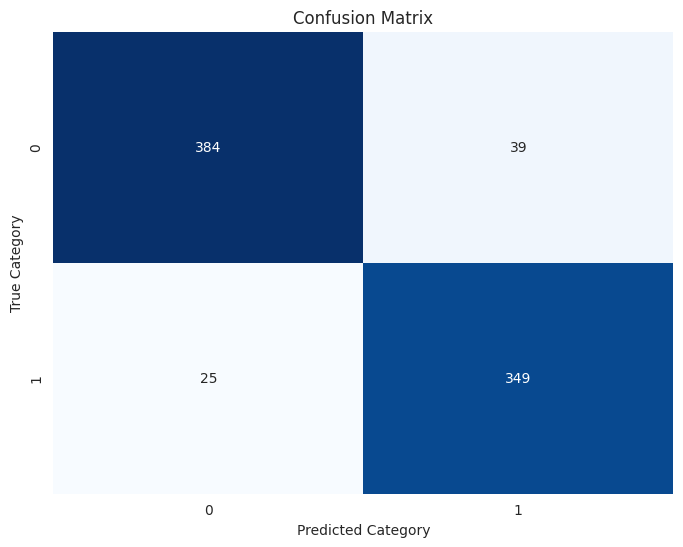

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the scaled test data using the correctly named model
y_pred_classified = dt_model.predict(X_test_scaled)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred_classified)
precision = precision_score(y_test, y_pred_classified, average='weighted')
recall = recall_score(y_test, y_pred_classified, average='weighted')
f1 = f1_score(y_test, y_pred_classified, average='weighted')

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classified)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.show()

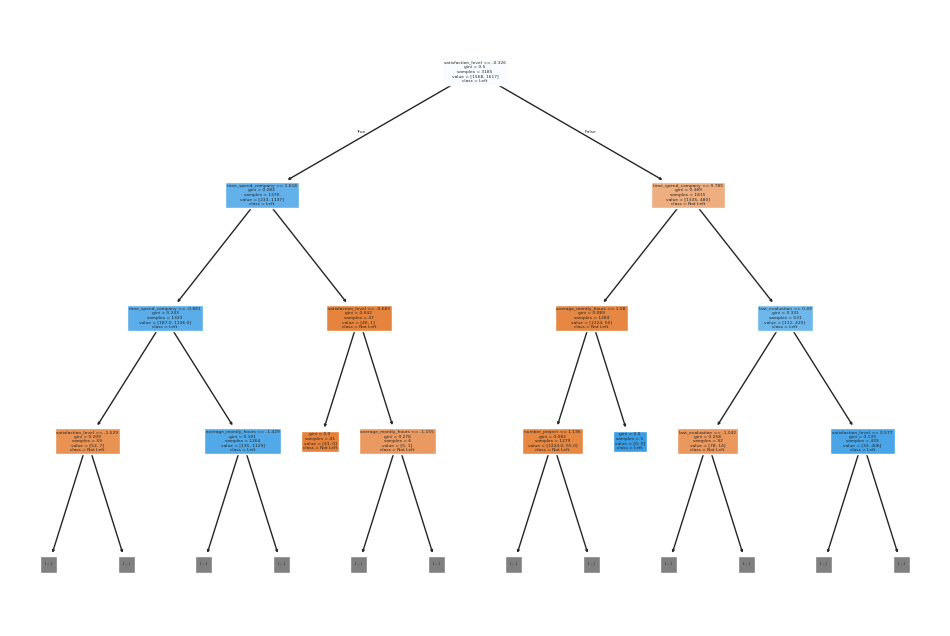

In [35]:
from sklearn import tree
import matplotlib.pyplot as plt

# Use the trained Decision Tree Classifier model (dt_model)
# Use the features used for training (X_train)
# Use the classes from the training target (y_train)

plt.figure(figsize=(12,8))

# Get the unique class labels from the training target
unique_classes = sorted(y_train.unique())

# Define meaningful class names based on the target variable 'left' (0=Not Left, 1=Left)
class_names_list = ['Not Left', 'Left']


tree.plot_tree(dt_model, filled=True, feature_names=X_train.columns.tolist(), class_names=class_names_list, max_depth=3)
plt.show()

Feature Importances (sorted):
satisfaction_level        0.398895
time_spend_company        0.362921
last_evaluation           0.100177
average_montly_hours      0.084970
number_project            0.018734
Department_technical      0.006660
salary_low                0.005952
salary_medium             0.004802
Department_sales          0.004165
Department_support        0.004117
Work_accident             0.003238
Department_product_mng    0.001150
Department_accounting     0.000998
Department_management     0.000971
Department_hr             0.000971
Department_marketing      0.000720
Department_RandD          0.000561
promotion_last_5years     0.000000
dtype: float64


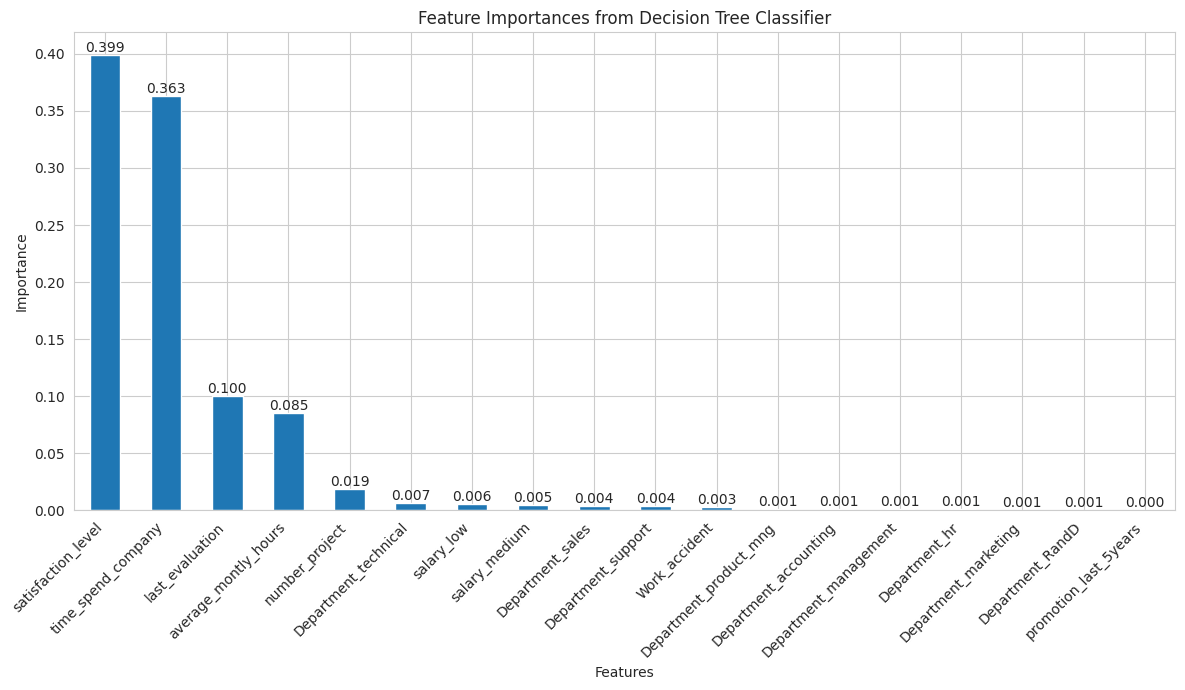

In [37]:

# Get feature importances from the trained model
feature_importances = dt_model.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Feature Importances (sorted):")
print(sorted_feature_importances)

# Optional: Visualize feature importances
plt.figure(figsize=(12, 7)) # Increased figure size slightly for better readability
ax = sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Format the labels to 3 decimal places

plt.show()